# 02 - Exploratory Data Analysis (EDA): Walmart Weekly Sales

This notebook performs exploratory analysis on the cleaned Walmart weekly sales dataset.

**Main goals:**
- Understand overall sales patterns over time.
- Examine store-level and department-level differences (if present).
- Identify seasonality and holiday effects.
- Calculate demand volatility.
- Produce plots and tables to support modelling decisions in later notebooks.


In [2]:
# Load cleaned dataset and import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Notebook displays
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Paths
PROJECT_ROOT = Path.cwd().resolve().parent
DATA_CLEAN = PROJECT_ROOT / "data" / "clean"

clean_path = DATA_CLEAN / "walmart_sales_clean.csv"

# Load cleaned dataset
df = pd.read_csv(clean_path, parse_dates=["date"])

print("Data loaded from:", clean_path)
print("Shape:", df.shape)
df.head()


Data loaded from: C:\Users\Mist\Documents\Portfolio\P1. Retail Sales Forecasting and Stock Optimisation\data\clean\walmart_sales_clean.csv
Shape: (6435, 8)


,store,date,weekly_sales,holiday_flag,temperature,fuel_price,cpi,unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


## Basic dataset overview

We inspect:

- Column names
- Data types
- Date range
- Number of stores
- Summary statistics

This helps confirm the dataset is ready for deeper analysis.


In [10]:
# Print the list of columns to verify the dataset structure
print("Columns:", df.columns.tolist())

# Display information about data types and non-null counts
# This helps confirm data integrity and ensures types are suitable for analysis
df.info()

# Show the earliest and latest dates in the dataset
# Useful for understanding the time span covered by the sales data
print("\nDate range:", df["date"].min(), "to", df["date"].max())

# Count the number of unique stores included in the dataset
# Helps understand dataset granularity and coverage
print("Number of stores:", df["store"].nunique())


Columns: ['store', 'date', 'weekly_sales', 'holiday_flag', 'temperature', 'fuel_price', 'cpi', 'unemployment']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   store         6435 non-null   int64         
 1   date          6435 non-null   datetime64[ns]
 2   weekly_sales  6435 non-null   float64       
 3   holiday_flag  6435 non-null   int64         
 4   temperature   6435 non-null   float64       
 5   fuel_price    6435 non-null   float64       
 6   cpi           6435 non-null   float64       
 7   unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB

Date range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00
Number of stores: 45


## Overall weekly sales trend

We aggregate sales across all stores for each week and plot the total weekly sales.

This helps identify:
- Long term trends
- Seasonal patterns
- Impact of holiday weeks


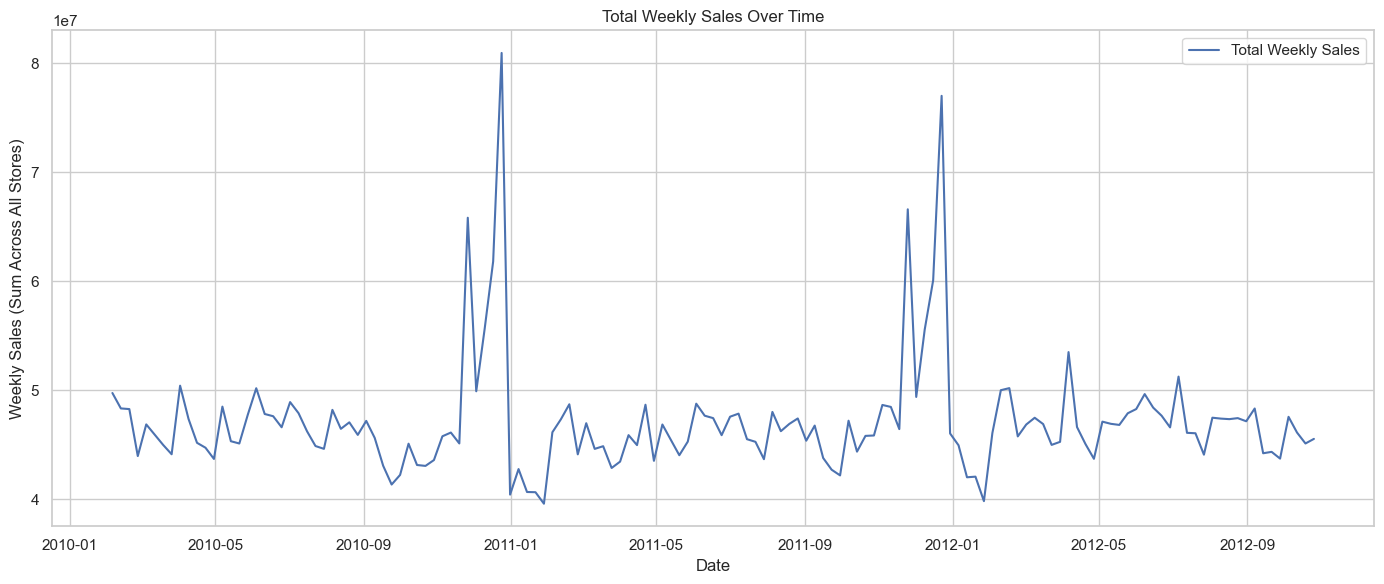

In [4]:
# Aggregate weekly sales across all stores
# Group by date and sum weekly sales to understand the overall trend
df_weekly = df.groupby("date")["weekly_sales"].sum().reset_index()

# Plot the aggregated weekly sales
plt.figure(figsize=(14, 6))
plt.plot(df_weekly["date"], df_weekly["weekly_sales"], label="Total Weekly Sales")

# Add labels and title for clarity
plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Weekly Sales (Sum Across All Stores)")
plt.legend()

# Ensures layout does not clip labels
plt.tight_layout()

# Display the plot
plt.show()


## Compare holiday vs non-holiday weekly sales

Holiday periods often show increased sales.

Here we calculate:
- Average weekly sales during holiday weeks
- Average weekly sales during normal weeks

Then visualise the comparison.


C:\Users\Mist\AppData\Local\Temp\ipykernel_10056\2886725273.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_holiday, x="holiday_flag", y="weekly_sales", palette="viridis")


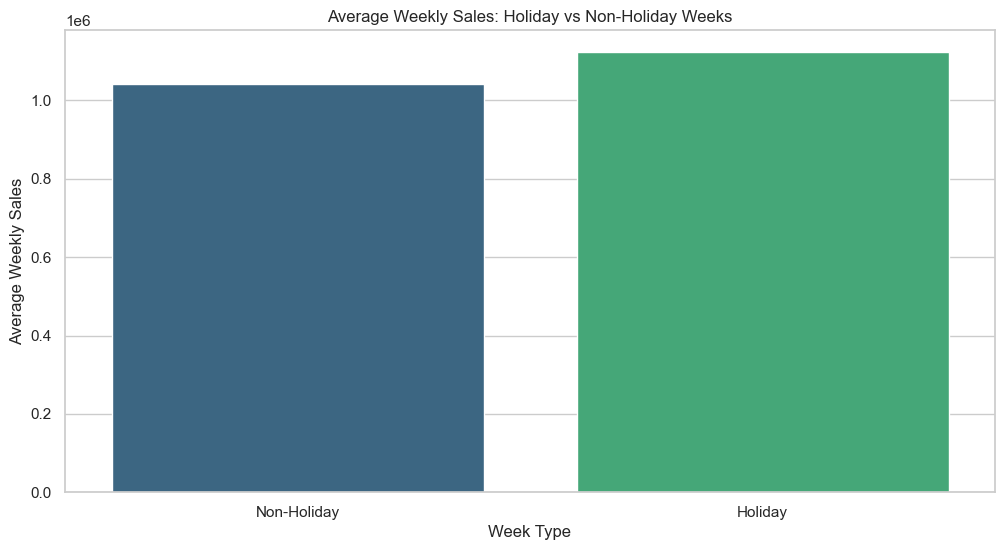

In [5]:
# Compute average weekly sales for holiday and non-holiday weeks
df_holiday = df.groupby("holiday_flag")["weekly_sales"].mean().reset_index()

# Map holiday_flag values to meaningful labels
df_holiday["holiday_flag"] = df_holiday["holiday_flag"].map({0: "Non-Holiday", 1: "Holiday"})

# Create bar plot of average sales for holiday vs non-holiday weeks
sns.barplot(data=df_holiday, x="holiday_flag", y="weekly_sales", palette="viridis")

# Add descriptive labels and title
plt.title("Average Weekly Sales: Holiday vs Non-Holiday Weeks")
plt.xlabel("Week Type")
plt.ylabel("Average Weekly Sales")

# Display the plot
plt.show()


## Store-level sales patterns

Stores can have very different sales volumes.

We:

- Calculate total sales per store.
- Visualise it using a barplot.
- Later analyse volatility and trend differences.


C:\Users\Mist\AppData\Local\Temp\ipykernel_10056\2993166246.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_store_totals, x="store", y="weekly_sales", palette="magma")


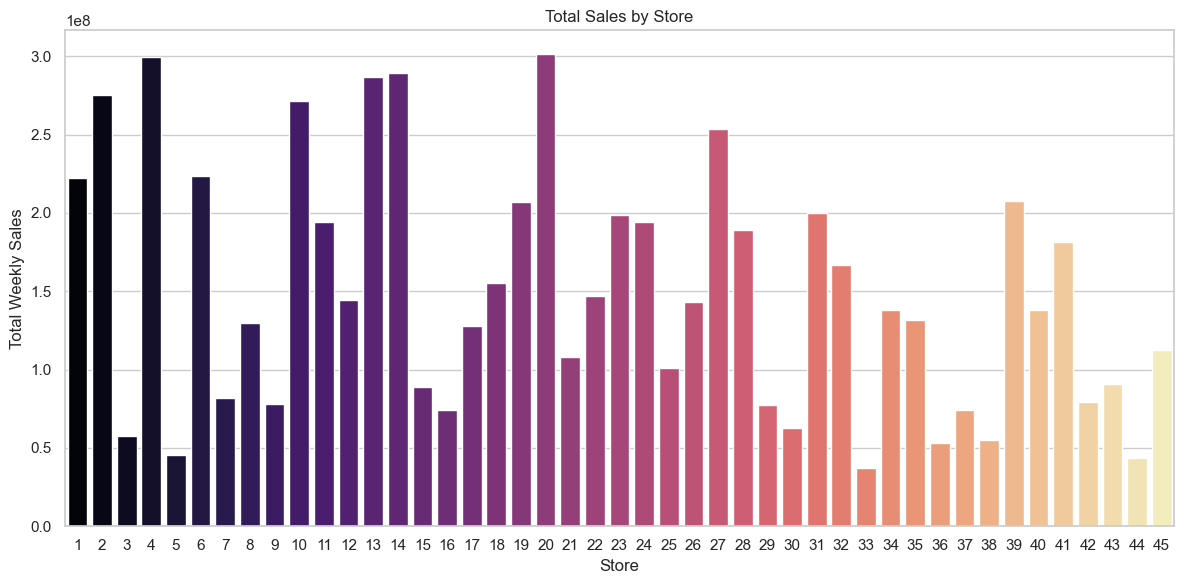

In [6]:
# Calculate total sales by store to identify high and low performing stores
df_store_totals = df.groupby("store")["weekly_sales"].sum().reset_index()

# Create a bar plot showing total sales per store
plt.figure(figsize=(12, 6))
sns.barplot(data=df_store_totals, x="store", y="weekly_sales", palette="magma")

# Add informative labels and title
plt.title("Total Sales by Store")
plt.xlabel("Store")
plt.ylabel("Total Weekly Sales")

# Tidy up spacing
plt.tight_layout()

# Display the chart
plt.show()


## Volatility analysis per store

Volatility is calculated as:

**coefficient of variation = std / mean**

Stores with higher volatility are harder to forecast.

This supports our modelling and stock optimisation decisions later.


In [7]:
# Calculate mean and standard deviation of weekly sales per store
df_vol = df.groupby("store")["weekly_sales"].agg(["mean", "std"])

# Calculate volatility as coefficient of variation: std / mean
df_vol["volatility"] = df_vol["std"] / df_vol["mean"]

# Reset index and sort stores by volatility descending
df_vol = df_vol.reset_index().sort_values("volatility", ascending=False)

# Display first 10 most volatile stores
df_vol.head(10)


,store,mean,std,volatility
34,35,9.197250e+05,211243.457791,0.229681
6,7,5.706173e+05,112585.469220,0.197305
14,15,6.233125e+05,120538.652043,0.193384
28,29,5.394514e+05,99120.136596,0.183742
22,23,1.389864e+06,249788.038068,0.179721
20,21,7.560691e+05,128752.812853,0.170292
44,45,7.859814e+05,130168.526635,0.165613
15,16,5.192477e+05,85769.680133,0.165181
17,18,1.084718e+06,176641.510839,0.162845
35,36,3.735120e+05,60725.173579,0.162579


## Visualise store-level volatility

This chart highlights which stores experience the most unstable sales patterns.


C:\Users\Mist\AppData\Local\Temp\ipykernel_10056\2009657855.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_vol, x="store", y="volatility", palette="flare")


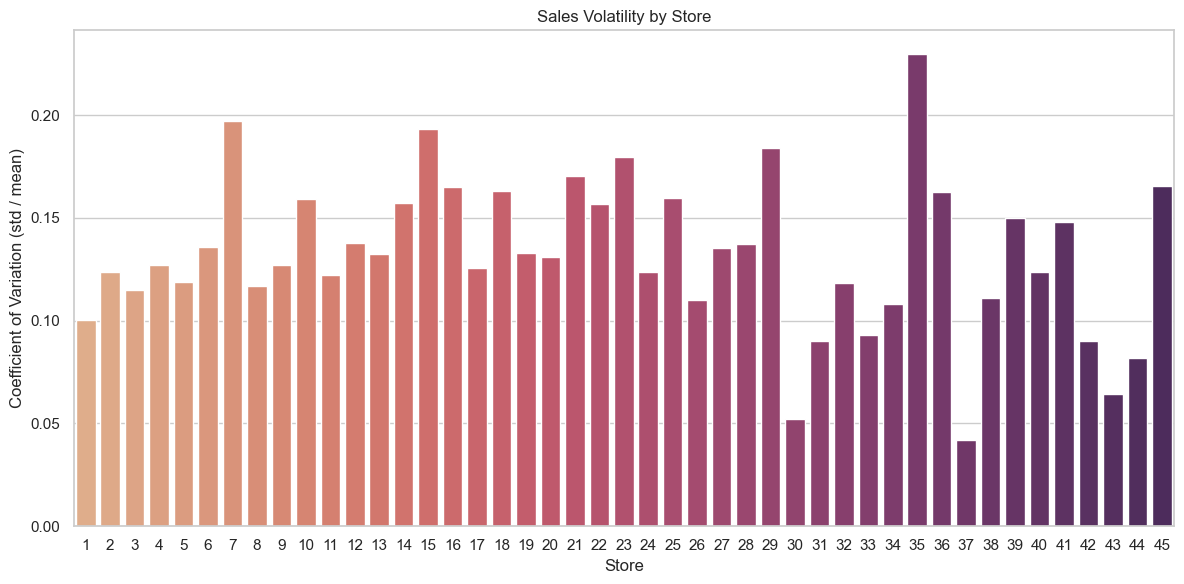

In [8]:
# Create a bar plot displaying volatility by store
plt.figure(figsize=(12, 6))
sns.barplot(data=df_vol, x="store", y="volatility", palette="flare")

# Add title and axis labels for context
plt.title("Sales Volatility by Store")
plt.xlabel("Store")
plt.ylabel("Coefficient of Variation (std / mean)")

# Adjust layout to prevent label overlap
plt.tight_layout()

# Display the plot
plt.show()


## Save EDA key tables for later use

Saving:

- Volatility table
- Weekly aggregated totals

These will support forecasting and stock optimisation notebooks.


In [9]:
# Define output directory for processed data
OUTPUT_PATH = PROJECT_ROOT / "data" / "processed"

# Ensure the directory exists, create if it does not
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

# Save volatility table to CSV
df_vol.to_csv(OUTPUT_PATH / "volatility_by_store.csv", index=False)

# Save aggregated weekly totals to CSV
df_weekly.to_csv(OUTPUT_PATH / "weekly_total_sales.csv", index=False)

# Print confirmation and paths
print("Saved EDA outputs:")
print("-", OUTPUT_PATH / "volatility_by_store.csv")
print("-", OUTPUT_PATH / "weekly_total_sales.csv")


Saved EDA outputs:
- C:\Users\Mist\Documents\Portfolio\P1. Retail Sales Forecasting and Stock Optimisation\data\processed\volatility_by_store.csv
- C:\Users\Mist\Documents\Portfolio\P1. Retail Sales Forecasting and Stock Optimisation\data\processed\weekly_total_sales.csv
